In [1]:
!cd /content/shopify-tagger && git pull

Already up to date.


In [9]:
!rm -rf /content/shopify-tagger/data/raw/amazon/


In [2]:
!rm -rf ~/.cache/huggingface/

In [1]:
# !git clone https://github.com/fdogarro/shopify-tagger.git
# !pip install -q -r shopify-tagger/requirements.txt
# %cd shopify-tagger/notebooks

In [3]:
import sys, os, json, logging, time
from pathlib import Path
import subprocess # Added for git clone

# --- Start of added environment setup for self-contained execution ---
REPO_URL = 'https://github.com/fdogarro/shopify-tagger.git'
PROJECT_DIR_NAME = 'shopify-tagger'
COLAB_CONTENT_DIR = Path('/content')
PROJECT_ROOT_PATH = COLAB_CONTENT_DIR / PROJECT_DIR_NAME
NOTEBOOKS_SUBDIR = 'notebooks'
EXPECTED_CWD_PATH = PROJECT_ROOT_PATH / NOTEBOOKS_SUBDIR

# 1. Clone the repository if it doesn't exist in /content/
if not PROJECT_ROOT_PATH.exists():
    print(f"Cloning '{REPO_URL}' into '{PROJECT_ROOT_PATH}'...")
    try:
        subprocess.run(['git', 'clone', REPO_URL, str(PROJECT_ROOT_PATH)], check=True, capture_output=True, text=True)
        print("Repository cloned successfully.")
        # Install requirements, as originally in cell-000
        requirements_file = PROJECT_ROOT_PATH / 'requirements.txt'
        if requirements_file.exists():
            print(f"Installing requirements from '{requirements_file}'...")
            subprocess.run(['pip', 'install', '-q', '-r', str(requirements_file)], check=True, capture_output=True, text=True)
            print("Requirements installed.")
    except subprocess.CalledProcessError as e:
        print(f"Error during repository cloning or requirements installation:")
        print(f"STDOUT: {e.stdout}")
        print(f"STDERR: {e.stderr}")
        sys.exit(1)
    except FileNotFoundError:
        print("Git or Pip command not found. Please ensure these tools are installed.")
        sys.exit(1)

# 2. Ensure current working directory is the 'notebooks' subdirectory
current_cwd = Path(os.getcwd())
if current_cwd != EXPECTED_CWD_PATH:
    if EXPECTED_CWD_PATH.exists():
        print(f"Changing directory from '{current_cwd}' to '{EXPECTED_CWD_PATH}'...")
        os.chdir(EXPECTED_CWD_PATH)
        print(f"Current working directory: '{os.getcwd()}'")
    else:
        print(f"Error: Expected notebooks directory '{EXPECTED_CWD_PATH}' not found after cloning. "
              f"Please check the repository structure.")
        sys.exit(1)

# At this point, os.getcwd() should be EXPECTED_CWD_PATH (/content/shopify-tagger/notebooks).
# The original code's sys.path.insert(0, str(Path('..').resolve()))
# will correctly add /content/shopify-tagger to sys.path.
# --- End of added environment setup ---


# Original code starts here (modified slightly for clarity and to remove redundant chdir logic)
_here = Path(os.getcwd())
# The following 'if' block becomes largely redundant after the explicit chdir above
# but is left for minimal modification. The crucial sys.path.insert will still work.
if _here.name != NOTEBOOKS_SUBDIR:
    _nb = _here / NOTEBOOKS_SUBDIR
    if _nb.exists():
        os.chdir(_nb)
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

from data.taxonomy_mapper import TaxonomyMapper
from data.amazon_loader import AmazonLoader
from data.dataset_builder import DatasetBuilder
from data.product_dataset import ProductDataset
from agents.preprocessor import Preprocessor
from models.bert_classifier import BertMultiLabelClassifier, BertTrainer, predict_batch
from models.bert_classifier import measure_latency as bert_measure_latency
from models.lora_mistral import build_model_and_tokenizer, LoraMistralTrainer, LoraMistralClassifier
from models.lora_mistral import measure_latency as lora_measure_latency
from models.llm_api import LLMApiTagger, FEW_SHOT_EXAMPLES
from eval.metrics import compute_metrics, tune_thresholds, per_label_f1, compare_models

logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
sns.set_theme(style='whitegrid', palette='muted')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('Environment OK')

Changing directory from '/content' to '/content/shopify-tagger/notebooks'...
Current working directory: '/content/shopify-tagger/notebooks'
Device: cuda
GPU:  NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Environment OK


In [69]:
!pip show anthropic

Name: anthropic
Version: 0.100.0
Summary: The official Python library for the anthropic API
Home-page: https://github.com/anthropics/anthropic-sdk-python
Author: 
Author-email: Anthropic <support@anthropic.com>
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: anyio, distro, docstring-parser, httpx, jiter, pydantic, sniffio, typing-extensions
Required-by: 


# Phase 1: Data Preparation & Taxonomy Validation

**CSCI E-222 · Spring 2026**

# Phase 1: Data Preparation & Taxonomy Validation

**CSCI E-222 · Spring 2026**

This notebook covers every step in Phase 1:
1. Taxonomy inspection and label distribution
2. Amazon dataset download and category mapping
3. Preprocessing pipeline validation
4. Stratified train/val/test split
5. Class imbalance analysis and pos_weight computation

> **Flipkart holdout**: loaded and saved here but never inspected for label distribution until final evaluation.

## 1. Taxonomy Inspection

In [4]:
with open('../data/taxonomy.json') as f:
    taxonomy = json.load(f)

labels = taxonomy['labels']
print(f"Taxonomy version: {taxonomy['version']}")
print(f"Number of labels: {len(labels)}")
print()
for l in labels:
    print(f"  [{l['id']:2d}] {l['tag']:<20} {l['description']}")

Taxonomy version: 1.0
Number of labels: 30

  [ 0] electronics          Consumer electronics and components
  [ 1] computers            Laptops, desktops, peripherals
  [ 2] phones               Smartphones, tablets, accessories
  [ 3] audio                Headphones, speakers, microphones
  [ 4] cameras              Cameras, lenses, photography gear
  [ 5] tv-video             Televisions, monitors, projectors
  [ 6] clothing             Apparel and fashion items
  [ 7] shoes                Footwear for all genders and ages
  [ 8] jewelry              Jewelry and watches
  [ 9] bags                 Bags, luggage, backpacks
  [10] beauty               Skincare, makeup, personal care
  [11] health               Vitamins, supplements, medical devices
  [12] sports               Sports equipment and activewear
  [13] outdoors             Camping, hiking, outdoor recreation
  [14] home-kitchen         Home goods, cookware, kitchen tools
  [15] furniture            Indoor and outdoor furnit

In [5]:
# Verify TaxonomyMapper loads cleanly
from data.taxonomy_mapper import TaxonomyMapper

mapper = TaxonomyMapper('../data/taxonomy.json')

# Spot-check a few mappings
test_cases = [
    ('Electronics', 'Bluetooth Speaker', 'Wireless speaker with deep bass'),
    ('Clothing_Shoes_and_Jewelry', 'Nike Air Max', 'Running shoes for men'),
    ('Clothing_Shoes_and_Jewelry', 'Gold Necklace', '18k gold pendant necklace'),
    ('Health_and_Household', 'Vitamin C 1000mg', 'Immune support supplement'),
    ('Home_and_Kitchen', 'Cast Iron Skillet', 'Pre-seasoned 12-inch pan'),
]

print(f"{'Category':<35} {'Title':<30} {'Tags'}")
print('-' * 90)
for cat, title, desc in test_cases:
    vec = mapper.map(cat, title, desc)
    tags = mapper.tag_names(vec)
    print(f"{cat:<35} {title:<30} {tags}")

Category                            Title                          Tags
------------------------------------------------------------------------------------------
Electronics                         Bluetooth Speaker              ['electronics']
Clothing_Shoes_and_Jewelry          Nike Air Max                   ['shoes']
Clothing_Shoes_and_Jewelry          Gold Necklace                  ['jewelry']
Health_and_Household                Vitamin C 1000mg               ['health']
Home_and_Kitchen                    Cast Iron Skillet              ['home-kitchen']


## 2. Amazon Dataset Download

Downloads product metadata via HuggingFace Datasets. Raw files are cached to `data/raw/amazon/` and are gitignored.

In [6]:
from data.amazon_loader import AmazonLoader

loader = AmazonLoader(mapper, cache_dir='../data/raw/amazon')

# Set max_products to control corpus size. ~80K is the target.
amazon_df = loader.load(max_products=5_000,
categories=['Electronics', 'Clothing_Shoes_and_Jewelry', 'Home_and_Kitchen', 'Health_and_Household', 'Sports_and_Outdoors']
)

print(f"\nLoaded: {len(amazon_df):,} products")
amazon_df.head(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The repository for McAuley-Lab/Amazon-Reviews-2023 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/McAuley-Lab/Amazon-Reviews-2023.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y



Loaded: 5,000 products


,title,description,vendor,product_type,amazon_category,asin,labels
0,FS-1051 FATSHARK TELEPORTER V3 HEADSET,Teleporter V3 The “Teleporter V3” kit sets a n...,,Electronics,Electronics,B00MCW7G9M,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Ce-H22B12-S1 4Kx2K Hdmi 4Port,HDMI In - HDMI Out,,Electronics,Electronics,B00YT6XQSE,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Digi-Tatoo Decal Skin Compatible With MacBook ...,,,Electronics,Electronics,B07SM135LS,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [8]:
import os
from google.colab import drive

drive.mount('/content/drive')

# Define the target directory path
target_dir = '/content/drive/MyDrive/shopify-tagger'

# Create the directory if it does not exist
os.makedirs(target_dir, exist_ok=True)

# Save the DataFrame to the newly created or existing directory
amazon_df.to_parquet(os.path.join(target_dir, 'amazon_raw.parquet'), index=False)
print("Saved to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Drive.


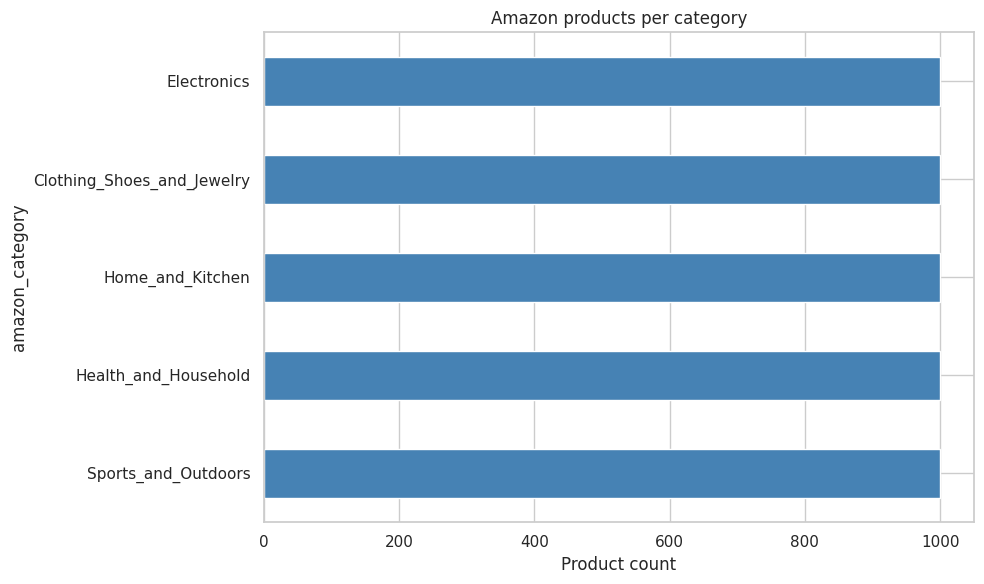

In [10]:
# Category distribution
cat_counts = amazon_df['amazon_category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
cat_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Product count')
ax.set_title('Amazon products per category')
ax.invert_yaxis()
plt.tight_layout()

# Create the directory if it doesn't exist
import os
from pathlib import Path
os.makedirs(Path('../data/processed'), exist_ok=True)

plt.savefig('../data/processed/category_distribution.png', dpi=150)
plt.show()

## 3. Preprocessing Pipeline Validation

In [11]:
from transformers import AutoTokenizer
from agents.preprocessor import Preprocessor

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
preprocessor = Preprocessor(tokenizer, min_length=20, max_length=120)

# Run on a sample
sample = amazon_df.sample(5, random_state=42).to_dict('records')
for product in sample:
    result = preprocessor.run(product)
    if result:
        n_tokens = len(result['input_ids'])
        print(f"  [{n_tokens:3d} tokens] {result['raw_title'][:60]}")
    else:
        print(f"  [SKIPPED] {product.get('title', '')[:60]}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  [ 40 tokens] Disney Toy Story Buzz , Woody 16" Kids School Backpack - 3d 
  [ 46 tokens] Lumbar Lower Back Pain Pillow-Bamboo Memory Foam Lumbar Supp
  [ 37 tokens] 6 Pack Mop Pad Accessories for iRobot Braava jet m6 Series U
  [120 tokens] KIDSCOOL SPACE Baby Toddler 2 Buttons Adjustable Straps Fash
  [ 58 tokens] SoundPEATS Frame S Smart Audio Glasses with Open Ear Earphon


Processed: 4,614 | Skipped (dup/short): 386
Token length — mean: 73.2 | median: 63 | p5: 23 | p95: 120


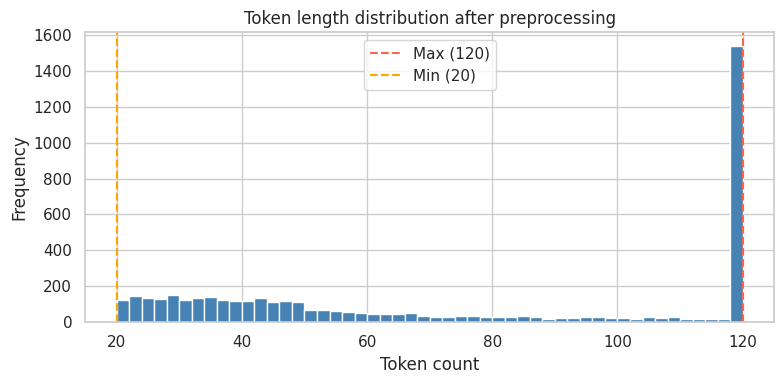

In [12]:
# Token length distribution across the full corpus
preprocessor.reset_dedup()
token_lengths = []
skipped = 0

for _, row in amazon_df.iterrows():
    result = preprocessor.run(row.to_dict())
    if result:
        token_lengths.append(len(result['input_ids']))
    else:
        skipped += 1

print(f"Processed: {len(token_lengths):,} | Skipped (dup/short): {skipped:,}")
print(f"Token length — mean: {np.mean(token_lengths):.1f} | median: {np.median(token_lengths):.0f} "
      f"| p5: {np.percentile(token_lengths, 5):.0f} | p95: {np.percentile(token_lengths, 95):.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(token_lengths, bins=50, color='steelblue', edgecolor='white')
ax.axvline(120, color='tomato', linestyle='--', label='Max (120)')
ax.axvline(20, color='orange', linestyle='--', label='Min (20)')
ax.set_xlabel('Token count')
ax.set_ylabel('Frequency')
ax.set_title('Token length distribution after preprocessing')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/token_length_dist.png', dpi=150)
plt.show()

## 4. Stratified Train / Val / Test Split

In [13]:
from data.dataset_builder import DatasetBuilder

builder = DatasetBuilder(num_labels=30)

# Flipkart holdout: load your Flipkart CSV here before calling build().
# It must have 'title', 'description', and 'labels' columns.
# flipkart_df = pd.read_csv('../data/raw/flipkart/flipkart_products.csv')
flipkart_df = None  # swap in when the Flipkart data is available

splits = builder.build(amazon_df, flipkart_df)
train_df, val_df, test_df = splits['train'], splits['val'], splits['test']

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Train: 4,000 | Val: 500 | Test: 500


## 5. Class Imbalance Analysis

In [ ]:
with open('../data/processed/stats.json') as f:
    stats = json.load(f)

print(f"Average labels per product: {stats['avg_labels_per_product']}")
print(f"Label coverage (labels with ≥1 sample): {stats['label_coverage_pct']}%")
print()

tag_names = [l['tag'] for l in labels]
pos_counts = stats['per_label_pos_counts']
pos_weights = stats['per_label_pos_weights']

imbalance_df = pd.DataFrame({
    'label': tag_names,
    'pos_count': pos_counts,
    'pos_weight': pos_weights,
}).sort_values('pos_count', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive counts
axes[0].barh(imbalance_df['label'], imbalance_df['pos_count'], color='steelblue')
axes[0].set_xlabel('Positive samples (train set)')
axes[0].set_title('Positive count per label')

# Pos weights
axes[1].barh(imbalance_df['label'], imbalance_df['pos_weight'], color='coral')
axes[1].set_xlabel('pos_weight (neg/pos ratio)')
axes[1].set_title('BCEWithLogitsLoss pos_weight per label')

plt.tight_layout()
plt.savefig('../data/processed/class_imbalance.png', dpi=150)
plt.show()

print('\nTop 5 most imbalanced labels (highest pos_weight):')
print(imbalance_df.sort_values('pos_weight', ascending=False).head(5)[['label', 'pos_count', 'pos_weight']].to_string(index=False))

In [14]:
# Verify no label leakage: each label should appear in all three splits
def label_coverage_per_split(df, name):
    matrix = np.array(df['labels'].tolist())
    covered = (matrix.sum(axis=0) > 0).sum()
    print(f"{name:8s}: {covered}/30 labels covered")

label_coverage_per_split(train_df, 'Train')
label_coverage_per_split(val_df,   'Val')
label_coverage_per_split(test_df,  'Test')
print()
print('Phase 1 complete. Splits saved to data/processed/')

Train   : 10/30 labels covered
Val     : 9/30 labels covered
Test    : 9/30 labels covered

Phase 1 complete. Splits saved to data/processed/


---
# Phase 2: BERT / RoBERTa Baseline Training

**Expected runtime on A100:** 30–60 min per model.

In [16]:
# Variables carried over from Phase 1
LABEL_NAMES = [l['tag'] for l in labels]
NUM_LABELS  = len(LABEL_NAMES)

# Use the 'stats' dictionary already available from the 'splits' variable
stats = splits['stats']
POS_WEIGHTS = stats['per_label_pos_weights']

print(f'Labels: {NUM_LABELS}')
print(f'Train: {stats["n_train"]:,} | Val: {stats["n_val"]:,} | Test: {stats["n_test"]:,}')
print(f'Avg labels per product: {stats["avg_labels_per_product"]}')

Labels: 30
Train: 4,000 | Val: 500 | Test: 500
Avg labels per product: 1.194


In [18]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/shopify-tagger', exist_ok=True)

amazon_df.to_parquet('/content/drive/MyDrive/shopify-tagger/amazon_raw.parquet', index=False)
train_df.to_parquet('/content/drive/MyDrive/shopify-tagger/train.parquet', index=False)
val_df.to_parquet('/content/drive/MyDrive/shopify-tagger/val.parquet', index=False)
test_df.to_parquet('/content/drive/MyDrive/shopify-tagger/test.parquet', index=False)
print("All splits saved to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All splits saved to Drive.


# Phase 2: BERT / RoBERTa Baseline Training

**CSCI E-222 · Spring 2026**

This notebook trains the multi-label BERT and RoBERTa classifiers, tunes per-label thresholds on the validation set, and logs all evaluation metrics. The best checkpoint serves as the latency and performance baseline for Phases 3–5.

**Expected runtime on A100:** 30–60 min per model.

## 1. Load Taxonomy & Dataset Stats

## 2. Training Configuration

Change `MODEL_NAME` to `'roberta-base'` to train the RoBERTa variant.

In [19]:
MODEL_NAME  = 'bert-base-uncased'   # swap to 'roberta-base' for RoBERTa run
BATCH_SIZE  = 32
NUM_EPOCHS  = 5
MAX_LENGTH  = 120
CHECKPOINT  = f'../checkpoints/{MODEL_NAME.replace("/", "-")}'

TRAIN_CONFIG = {
    'learning_rate': 2e-5,
    'weight_decay':  0.01,
    'num_epochs':    NUM_EPOCHS,
    'max_grad_norm': 1.0,
    'batch_size':    BATCH_SIZE,
    'max_length':    MAX_LENGTH,
    'model_name':    MODEL_NAME,
}

print(json.dumps(TRAIN_CONFIG, indent=2))

{
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "num_epochs": 5,
  "max_grad_norm": 1.0,
  "batch_size": 32,
  "max_length": 120,
  "model_name": "bert-base-uncased"
}


## 3. DataLoaders

In [21]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = ProductDataset('data/processed/train.parquet', tokenizer, MAX_LENGTH, NUM_LABELS)
val_ds   = ProductDataset('data/processed/val.parquet',   tokenizer, MAX_LENGTH, NUM_LABELS)
test_ds  = ProductDataset('data/processed/test.parquet',  tokenizer, MAX_LENGTH, NUM_LABELS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 125 | Val batches: 16 | Test batches: 16


## 4. Train

In [22]:
model = BertMultiLabelClassifier(MODEL_NAME, NUM_LABELS)

trainer = BertTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TRAIN_CONFIG,
    checkpoint_dir=CHECKPOINT,
    pos_weight=POS_WEIGHTS,
    device=DEVICE,
)

results = trainer.train()
print(f"\nBest Micro-F1: {results['best_micro_f1']:.4f}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Best Micro-F1: 0.8718


## 5. Loss & F1 Curves

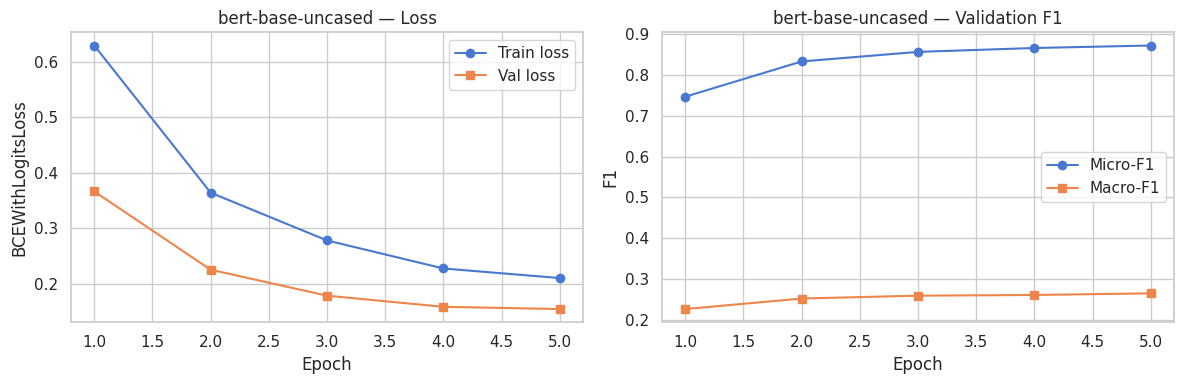

In [23]:
history = results['history']
epochs  = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(epochs, history['train_loss'], label='Train loss', marker='o')
axes[0].plot(epochs, history['val_loss'],   label='Val loss',   marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCEWithLogitsLoss')
axes[0].set_title(f'{MODEL_NAME} — Loss')
axes[0].legend()

# F1 curves
axes[1].plot(epochs, history['micro_f1'], label='Micro-F1', marker='o')
axes[1].plot(epochs, history['macro_f1'], label='Macro-F1', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_title(f'{MODEL_NAME} — Validation F1')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'../data/processed/{MODEL_NAME.replace("/", "-")}_curves.png', dpi=150)
plt.show()

## 6. Evaluate Best Checkpoint on Test Set

In [24]:
best_model = BertMultiLabelClassifier.from_checkpoint(CHECKPOINT)
best_model.eval().to(DEVICE)

best_thresholds = results['best_thresholds']

all_probs, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch.get('token_type_ids')
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)

        logits = best_model(input_ids, attention_mask, token_type_ids)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(batch['labels'].numpy())

y_prob = np.vstack(all_probs)
y_true = np.vstack(all_labels)

test_metrics = compute_metrics(y_true, y_prob, best_thresholds)

print('Test set results:')
for k, v in test_metrics.items():
    if k != 'per_label_f1':
        print(f'  {k:<20} {v}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Test set results:
  micro_f1             0.8392
  macro_f1             0.2451
  hamming_loss         0.0131
  coverage_error       1.478
  ranking_loss         0.009


## 7. Per-Label F1 Bar Chart

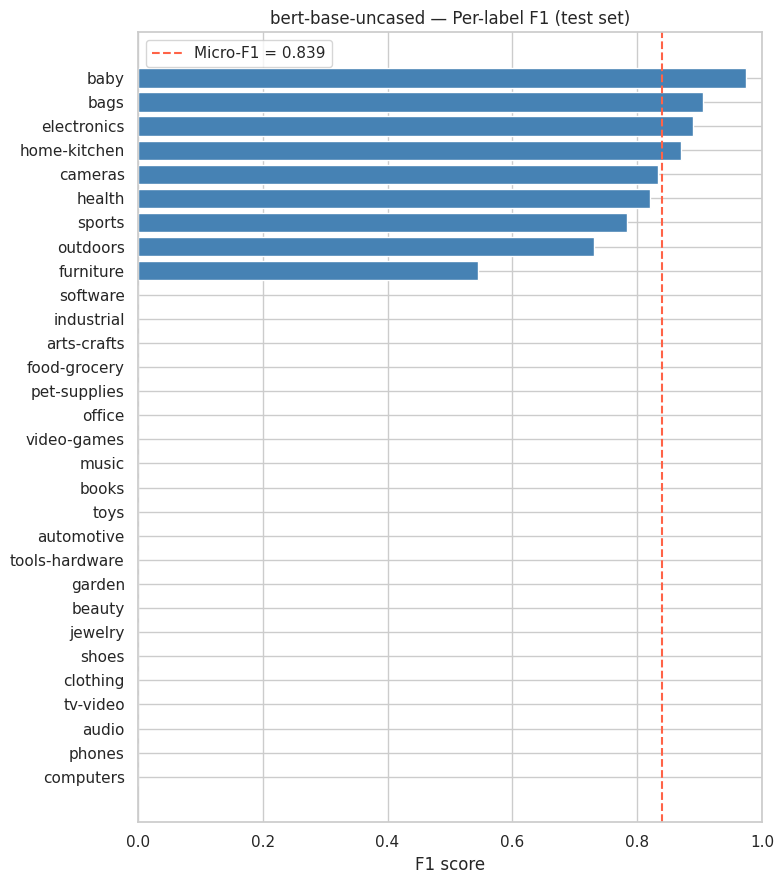

In [25]:
label_f1 = dict(zip(LABEL_NAMES, test_metrics['per_label_f1']))
sorted_items = sorted(label_f1.items(), key=lambda x: x[1])
names, scores = zip(*sorted_items)

fig, ax = plt.subplots(figsize=(8, 9))
bars = ax.barh(names, scores, color='steelblue')
ax.axvline(test_metrics['micro_f1'], color='tomato', linestyle='--', label=f'Micro-F1 = {test_metrics["micro_f1"]:.3f}')
ax.set_xlabel('F1 score')
ax.set_title(f'{MODEL_NAME} — Per-label F1 (test set)')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(f'../data/processed/{MODEL_NAME.replace("/", "-")}_per_label_f1.png', dpi=150)
plt.show()

## 8. Inference Latency

In [27]:
latency = bert_measure_latency(best_model, tokenizer, n_samples=200, max_length=MAX_LENGTH, device=DEVICE)

print('Inference latency (single sample, no batching):')
for k, v in latency.items():
    print(f'  {k:<12} {v} ms')

# Save latency results for Phase 3 comparison
with open(f'../data/processed/{MODEL_NAME.replace("/", "-")}_latency.json', 'w') as f:
    json.dump({'model': MODEL_NAME, **latency}, f, indent=2)

Inference latency (single sample, no batching):
  mean_ms      9.55 ms
  median_ms    9.21 ms
  p95_ms       9.44 ms
  p99_ms       11.07 ms


## 9. Threshold Report

In [28]:
threshold_df = pd.DataFrame({
    'label':     LABEL_NAMES,
    'threshold': best_thresholds,
    'test_f1':   test_metrics['per_label_f1'],
}).sort_values('test_f1')

print(threshold_df.to_string(index=False))

print('\nPhase 2 complete.')
print(f'Checkpoint saved to: {CHECKPOINT}')

         label  threshold  test_f1
     computers       0.50   0.0000
        phones       0.50   0.0000
         audio       0.50   0.0000
      tv-video       0.50   0.0000
         shoes       0.50   0.0000
      clothing       0.50   0.0000
        beauty       0.50   0.0000
       jewelry       0.50   0.0000
        office       0.50   0.0000
   video-games       0.50   0.0000
         music       0.50   0.0000
         books       0.50   0.0000
          toys       0.50   0.0000
    automotive       0.50   0.0000
tools-hardware       0.50   0.0000
        garden       0.50   0.0000
    industrial       0.50   0.0000
  pet-supplies       0.50   0.0000
  food-grocery       0.50   0.0000
   arts-crafts       0.50   0.0000
      software       0.50   0.0000
     furniture       0.80   0.5455
      outdoors       0.44   0.7312
        sports       0.41   0.7835
        health       0.61   0.8200
       cameras       0.89   0.8333
  home-kitchen       0.75   0.8705
   electronics      

---
# Phase 3: LoRA-Mistral-7B Training (QLoRA, 4-bit)

**Expected runtime on A100:** 3–6 hrs · **Peak VRAM:** ~18–24 GB

In [29]:
# Variables carried over from Phase 1 & 2
print(f'Labels: {NUM_LABELS} | Train: {stats["n_train"]:,} | Val: {stats["n_val"]:,}')

Labels: 30 | Train: 4,000 | Val: 500


# Phase 3: LoRA-Mistral-7B Training (QLoRA, 4-bit)

**CSCI E-222 · Spring 2026**

Trains a parameter-efficient LoRA adapter on Mistral-7B-Instruct-v0.2 for multi-label product tagging.
The backbone is frozen in 4-bit; only LoRA weights (`q_proj`, `v_proj`) and the classification head train.

**Expected runtime on A100:** 3–6 hrs · **Expected peak VRAM:** ~18–24 GB

Results are compared directly against the BERT baseline from Phase 2.

## 1. Load Taxonomy & Stats

## 2. Training Configuration

Batch size is kept small (4) due to Mistral's memory footprint.
Gradient accumulation over 8 steps gives an effective batch of 32 — matching the BERT baseline.

In [30]:
BATCH_SIZE     = 4       # physical batch — Mistral is memory-heavy
GRAD_ACCUM     = 8       # effective batch = 32 (matches BERT baseline)
NUM_EPOCHS     = 3       # QLoRA converges faster than full fine-tuning
MAX_LENGTH     = 120
CHECKPOINT_DIR = '../checkpoints/lora_mistral'

TRAIN_CONFIG = {
    'learning_rate':       2e-4,   # higher than BERT — LoRA params only
    'weight_decay':        0.01,
    'num_epochs':          NUM_EPOCHS,
    'max_grad_norm':       1.0,
    'batch_size':          BATCH_SIZE,
    'grad_accum_steps':    GRAD_ACCUM,
    'max_length':          MAX_LENGTH,
    'lora_r':              16,
    'lora_alpha':          32,
    'lora_dropout':        0.1,
    'target_modules':      ['q_proj', 'v_proj'],
}

print(json.dumps(TRAIN_CONFIG, indent=2))

{
  "learning_rate": 0.0002,
  "weight_decay": 0.01,
  "num_epochs": 3,
  "max_grad_norm": 1.0,
  "batch_size": 4,
  "grad_accum_steps": 8,
  "max_length": 120,
  "lora_r": 16,
  "lora_alpha": 32,
  "lora_dropout": 0.1,
  "target_modules": [
    "q_proj",
    "v_proj"
  ]
}


## 3. Build Model & Tokenizer

In [31]:
model, tokenizer = build_model_and_tokenizer(
    num_labels=NUM_LABELS,
    lora_r=TRAIN_CONFIG['lora_r'],
    lora_alpha=TRAIN_CONFIG['lora_alpha'],
    lora_dropout=TRAIN_CONFIG['lora_dropout'],
)

if torch.cuda.is_available():
    mem = torch.cuda.memory_allocated() / 1e9
    print(f'GPU memory after model load: {mem:.2f} GB')

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

GPU memory after model load: 6.97 GB


## 4. DataLoaders

Reuses `ProductDataset` from Phase 2 — same split files, same tokenization interface.
The Mistral tokenizer replaces the BERT tokenizer transparently.

In [33]:
processed_data_dir = Path('../data/processed')
processed_data_dir.mkdir(parents=True, exist_ok=True)

splits['train'].to_parquet(processed_data_dir / 'train.parquet', index=False)
splits['val'].to_parquet(processed_data_dir / 'val.parquet', index=False)
splits['test'].to_parquet(processed_data_dir / 'test.parquet', index=False)

train_ds = ProductDataset('../data/processed/train.parquet', tokenizer, MAX_LENGTH, NUM_LABELS)
val_ds   = ProductDataset('../data/processed/val.parquet',   tokenizer, MAX_LENGTH, NUM_LABELS)
test_ds  = ProductDataset('../data/processed/test.parquet',  tokenizer, MAX_LENGTH, NUM_LABELS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
print(f'Effective batch size: {BATCH_SIZE * GRAD_ACCUM} (after gradient accumulation)')

Train batches: 1000 | Val batches: 125
Effective batch size: 32 (after gradient accumulation)


## 5. Train

In [34]:
trainer = LoraMistralTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TRAIN_CONFIG,
    checkpoint_dir=CHECKPOINT_DIR,
    pos_weight=POS_WEIGHTS,
)

results = trainer.train()
print(f"\nBest Micro-F1: {results['best_micro_f1']:.4f}")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on 


Best Micro-F1: 0.9434


## 6. Loss & F1 Curves

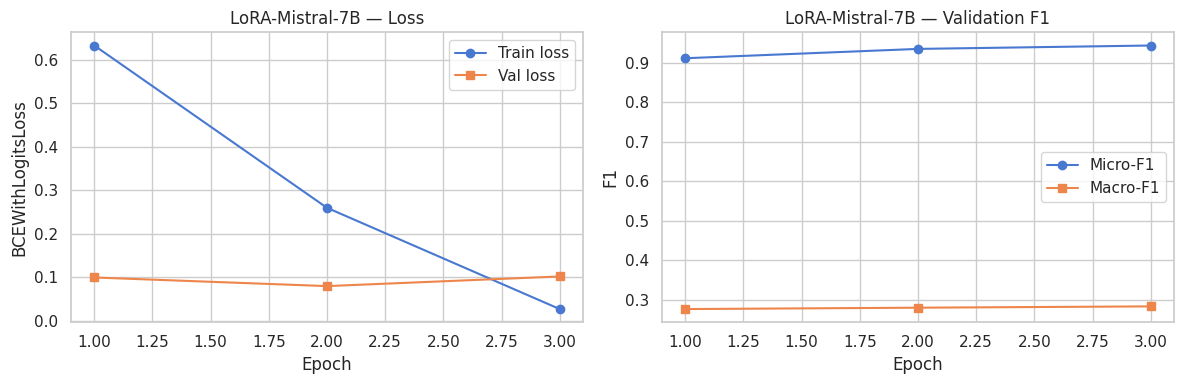

In [35]:
history = results['history']
epochs  = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], label='Train loss', marker='o')
axes[0].plot(epochs, history['val_loss'],   label='Val loss',   marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCEWithLogitsLoss')
axes[0].set_title('LoRA-Mistral-7B — Loss')
axes[0].legend()

axes[1].plot(epochs, history['micro_f1'], label='Micro-F1', marker='o')
axes[1].plot(epochs, history['macro_f1'], label='Macro-F1', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_title('LoRA-Mistral-7B — Validation F1')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/lora_mistral_curves.png', dpi=150)
plt.show()

## 7. Evaluate Best Checkpoint on Test Set

In [38]:
best_model = LoraMistralClassifier.from_checkpoint(CHECKPOINT_DIR, num_labels=NUM_LABELS)
# Ensure the classifier head's weights are set to bfloat16 to match the output dtype of the LoRA-Mistral backbone
best_model.classifier.to(torch.bfloat16)
best_model.eval().to(device)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

best_thresholds = results['best_thresholds']

all_probs, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        logits = best_model(input_ids, attention_mask)
        probs  = torch.sigmoid(logits).cpu().float().numpy()
        all_probs.append(probs)
        all_labels.append(batch['labels'].numpy())

y_prob = np.vstack(all_probs)
y_true = np.vstack(all_labels)

lora_metrics = compute_metrics(y_true, y_prob, best_thresholds)

print('LoRA-Mistral test set results:')
for k, v in lora_metrics.items():
    if k != 'per_label_f1':
        print(f'  {k:<20} {v}')

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

LoRA-Mistral test set results:
  micro_f1             0.9188
  macro_f1             0.2741
  hamming_loss         0.0065
  coverage_error       1.322
  ranking_loss         0.0037


## 8. Head-to-Head Comparison with BERT Baseline

In [39]:
# Load BERT test results saved in Phase 2
# (Re-run Phase 2 eval cell if metrics weren't persisted)
bert_model_name = 'bert-base-uncased'

# Summary table
summary_rows = []
metrics_to_show = ['micro_f1', 'macro_f1', 'hamming_loss', 'coverage_error', 'ranking_loss']

# You'll have bert_metrics from Phase 2 in the same Colab session,
# or reload the checkpoint and re-evaluate here.
# For now, this cell expects `bert_metrics` to be defined.
try:
    comparison = compare_models(
        {'BERT': bert_metrics, 'LoRA-Mistral': lora_metrics},
        LABEL_NAMES
    )
    summary_df = pd.DataFrame(comparison['summary']).T
    print('Model comparison (test set):')
    print(summary_df.to_string())
    summary_df.to_csv('../data/processed/model_comparison.csv')
except NameError:
    print('bert_metrics not in scope — run Phase 2 eval in the same session or reload the checkpoint.')

bert_metrics not in scope — run Phase 2 eval in the same session or reload the checkpoint.


## 9. Per-Label F1 Comparison Heatmap

In [40]:
try:
    heatmap_data = pd.DataFrame({
        'BERT':         bert_metrics['per_label_f1'],
        'LoRA-Mistral': lora_metrics['per_label_f1'],
    }, index=LABEL_NAMES)

    # Sort by average F1 descending
    heatmap_data['avg'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('avg', ascending=False).drop(columns='avg')

    fig, ax = plt.subplots(figsize=(7, 11))
    sns.heatmap(
        heatmap_data,
        annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=0, vmax=1,
        linewidths=0.5, ax=ax,
    )
    ax.set_title('Per-label F1: BERT vs LoRA-Mistral (test set)')
    ax.set_xlabel('Model')
    plt.tight_layout()
    plt.savefig('../data/processed/per_label_f1_heatmap_phase3.png', dpi=150)
    plt.show()
except NameError:
    print('bert_metrics not in scope — skipping heatmap.')

bert_metrics not in scope — skipping heatmap.


## 10. Latency Comparison

This gap directly informs the Model Selector's confidence threshold in Phase 5:
the higher the latency penalty for routing to Mistral, the tighter the threshold needs to be.

In [ ]:
lora_latency = measure_latency(best_model, tokenizer, n_samples=50, max_length=MAX_LENGTH)

print('LoRA-Mistral inference latency (single sample):')
for k, v in lora_latency.items():
    print(f'  {k:<12} {v} ms')

with open('../data/processed/lora_mistral_latency.json', 'w') as f:
    json.dump({'model': 'lora_mistral', **lora_latency}, f, indent=2)

# Load BERT latency for comparison
try:
    with open(f'../data/processed/{bert_model_name}_latency.json') as f:
        bert_latency = json.load(f)

    print(f'\nLatency ratio (Mistral / BERT):')
    for k in ['mean_ms', 'p95_ms']:
        ratio = lora_latency[k] / bert_latency[k]
        print(f'  {k:<12} {ratio:.1f}x slower')
except FileNotFoundError:
    print('BERT latency file not found — run Phase 2 notebook first.')

In [41]:
print('Phase 3 complete.')
print(f'LoRA adapter + classifier head saved to: {CHECKPOINT_DIR}')
print('Latency gap logged — use it to calibrate the Model Selector threshold in Phase 5.')

Phase 3 complete.
LoRA adapter + classifier head saved to: ../checkpoints/lora_mistral
Latency gap logged — use it to calibrate the Model Selector threshold in Phase 5.


---
# Phase 4: Few-Shot LLM API Baseline

# Phase 4: Few-Shot LLM API Baseline

**CSCI E-222 · Spring 2026**

Evaluates GPT-4o-mini and Claude Haiku as zero-training-cost baselines for multi-label product tagging.
Both models serve as the OOD fallback in the live pipeline (Phase 5).

This notebook:
1. Inspects the 5-shot prompt
2. Runs both providers on the test set (responses cached to disk)
3. Logs all metrics — same set as Phases 2 & 3 for direct comparison
4. Documents failure modes: hallucinated tags, parse failures, latency variance
5. Estimates per-call cost at scale

## 1. Inspect the 5-Shot Prompt

Review the prompt before running any API calls.

In [42]:
# Instantiate without making any API calls
tagger = LLMApiTagger(
    provider='anthropic',
    model='claude-haiku-4-5-20251001',
    taxonomy_path='../data/taxonomy.json',
    cache_dir='../data/raw/llm_cache',
)

sample_product = {'title': 'Example Product', 'description': 'A sample product for prompt inspection.'}
prompt = tagger._build_prompt(sample_product, FEW_SHOT_EXAMPLES)
print(prompt)

You are a product taxonomy classifier for an ecommerce store.
Given a product title and description, identify which tags from the list below apply.
Return ONLY a JSON array of applicable tag strings — no explanation, no markdown.
If no tags apply, return an empty array [].

Available tags: [electronics, computers, phones, audio, cameras, tv-video, clothing, shoes, jewelry, bags, beauty, health, sports, outdoors, home-kitchen, furniture, garden, tools-hardware, automotive, toys, baby, books, music, video-games, office, pet-supplies, food-grocery, arts-crafts, industrial, software]

--- Examples ---

Title: Sony WH-1000XM5 Wireless Noise Cancelling Headphones
Description: Industry-leading noise cancellation with 30-hour battery life. Foldable design, multipoint connection, and built-in Alexa.
Tags: ["electronics", "audio"]

Title: Nike Air Zoom Pegasus 41 Running Shoes
Description: Responsive cushioning for everyday training. Breathable mesh upper, React foam midsole, rubber outsole.
Tag

In [77]:
import os
os.environ["ANTHROPIC_API_KEY"] = os.environ["ANTHROPIC_API_KEY"].strip()

In [80]:
import os, anthropic

key = "YOUR_ANTHROPIC_API_KEY_HERE
print(f"Length: {len(key)}")
client = anthropic.Anthropic(api_key=key)
message = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=10,
    messages=[{"role": "user", "content": "say hi"}],
)
print(message.content[0].text)

Length: 108
Hi! 👋 How can I help


In [82]:
# Re-initialize the tagger to ensure it picks up the corrected environment variable
tagger = LLMApiTagger(
    provider='anthropic',
    model='claude-haiku-4-5-20251001',
    taxonomy_path='../data/taxonomy.json',
    cache_dir='../data/raw/llm_cache',
)
print("Tagger re-initialized with current environment variables.")

Tagger re-initialized with current environment variables.


## 2. Smoke Test (5 Products)

Verify the pipeline end-to-end before running the full test set.

In [83]:
import pandas as pd
test_df = pd.read_parquet('../data/processed/test.parquet')
smoke   = test_df.sample(5, random_state=0).to_dict('records')

print(f'Running smoke test on 5 products with Claude Haiku...\n')
for product in smoke:
    result = tagger.predict(product)
    print(f"  Title:   {product['title'][:60]}")
    print(f"  Tags:    {result['tags']}")
    if result['hallucinations']:
        print(f"  [HALLUC] {result['hallucinations']}")
    if result['failed']:
        print(f"  [FAILED] Could not parse response")
    print()

Running smoke test on 5 products with Claude Haiku...



AuthenticationError: Error code: 401 - {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'invalid x-api-key'}, 'request_id': 'req_011Can4BWnxb1qNw16ZC3XLL'}

In [58]:
print(os.environ.get("ANTHROPIC_API_KEY", "NOT SET"))

In [56]:
import anthropic
import os

try:
    client = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY'))
    # Attempt a minimal message to verify the key
    response = client.messages.create(
        model="claude-3-haiku-20240307",
        max_tokens=10,
        messages=[{"role": "user", "content": "Hello"}]
    )
    print("✅ Direct SDK Test Successful! The key is valid.")
except anthropic.AuthenticationError:
    print("❌ Direct SDK Test Failed: 401 Authentication Error.")
    print("Please double-check your key at https://console.anthropic.com/ and update your Colab Secret.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

❌ Direct SDK Test Failed: 401 Authentication Error.
Please double-check your key at https://console.anthropic.com/ and update your Colab Secret.


In [55]:
import anthropic
import os

try:
    client = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY'))
    # Attempt a minimal message to verify the key
    response = client.messages.create(
        model="claude-3-haiku-20240307",
        max_tokens=10,
        messages=[{"role": "user", "content": "Hello"}]
    )
    print("✅ Direct SDK Test Successful! The key is valid.")
except anthropic.AuthenticationError:
    print("❌ Direct SDK Test Failed: 401 Authentication Error.")
    print("Please double-check your key at https://console.anthropic.com/ and update your Colab Secret.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

❌ Direct SDK Test Failed: 401 Authentication Error.
Please double-check your key at https://console.anthropic.com/ and update your Colab Secret.


## 3. Full Test Set Evaluation — Claude Haiku

In [57]:
def evaluate_llm(provider: str, model: str, df: pd.DataFrame, label_names: list[str]) -> dict:
    """Run the full LLM evaluation loop and return metrics + telemetry."""
    tagger = LLMApiTagger(
        provider=provider,
        model=model,
        taxonomy_path='../data/taxonomy.json',
        cache_dir='../data/raw/llm_cache',
        request_delay=0.3,
    )

    all_preds, all_true = [], []
    latencies = []
    n = len(df)

    for i, row in df.iterrows():
        product = {'title': row['title'], 'description': row['description']}
        start   = time.perf_counter()
        result  = tagger.predict(product)
        latencies.append((time.perf_counter() - start) * 1000)

        all_preds.append(result['labels'])

        # Ground truth
        gt = row['labels']
        if isinstance(gt, str):
            import ast
            gt = ast.literal_eval(gt)
        all_true.append([int(v) for v in gt])

        if (i + 1) % 200 == 0:
            print(f'  {i+1}/{n} complete...')

    y_pred = np.array(all_preds)
    y_true = np.array(all_true)

    # LLM output is already binary — use 0.5 threshold (pass probs = binary pred)
    metrics  = compute_metrics(y_true, y_pred.astype(float), thresholds=[0.5] * len(label_names))
    failures = tagger.failure_report()
    cost     = tagger.cost_estimate(n_products=100_000)

    return {
        'metrics':   metrics,
        'failures':  failures,
        'cost':      cost,
        'latency':   {
            'mean_ms':   round(float(np.mean(latencies)), 2),
            'median_ms': round(float(np.median(latencies)), 2),
            'p95_ms':    round(float(np.percentile(latencies, 95)), 2),
            'p99_ms':    round(float(np.percentile(latencies, 99)), 2),
        },
    }


print('Evaluating Claude Haiku on test set...')
haiku_results = evaluate_llm(
    provider='anthropic',
    model='claude-haiku-4-5-20251001',
    df=test_df,
    label_names=LABEL_NAMES,
)

print('\nClaude Haiku — test set metrics:')
for k, v in haiku_results['metrics'].items():
    if k != 'per_label_f1':
        print(f'  {k:<20} {v}')

Evaluating Claude Haiku on test set...


AuthenticationError: Error code: 401 - {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'invalid x-api-key'}, 'request_id': 'req_011Can2aV9Q4bViNogtHiodD'}

## 4. Full Test Set Evaluation — GPT-4o-mini

In [ ]:
print('Evaluating GPT-4o-mini on test set...')
gpt_results = evaluate_llm(
    provider='openai',
    model='gpt-4o-mini',
    df=test_df,
    label_names=LABEL_NAMES,
)

print('\nGPT-4o-mini — test set metrics:')
for k, v in gpt_results['metrics'].items():
    if k != 'per_label_f1':
        print(f'  {k:<20} {v}')

## 5. Three-Way Comparison Table

Assumes `bert_metrics` and `lora_metrics` are in scope from Phases 2 & 3.
If not, reload those checkpoints and re-evaluate before running this cell.

In [ ]:
try:
    all_results = {
        'BERT':           bert_metrics,
        'LoRA-Mistral':   lora_metrics,
        'Claude Haiku':   haiku_results['metrics'],
        'GPT-4o-mini':    gpt_results['metrics'],
    }

    comparison = compare_models(all_results, LABEL_NAMES)
    summary_df = pd.DataFrame(comparison['summary']).T

    print('All-model comparison (test set):')
    print(summary_df.to_string())

    summary_df.to_csv('../data/processed/all_model_comparison.csv')
    print('\nSaved to data/processed/all_model_comparison.csv')
except NameError:
    print('bert_metrics / lora_metrics not in scope — run Phases 2 & 3 first or reload checkpoints.')

## 6. Failure Mode Analysis

In [ ]:
for name, res in [('Claude Haiku', haiku_results), ('GPT-4o-mini', gpt_results)]:
    f = res['failures']
    n = len(test_df)
    print(f'{name}:')
    print(f'  Parse failures:    {f["parse_failure_count"]} / {n} ({100*f["parse_failure_count"]/n:.1f}%)')
    print(f'  Hallucinations:    {f["hallucination_count"]} / {n} ({100*f["hallucination_count"]/n:.1f}%)')
    print()

# Show example failures
print('Sample failure events (Claude Haiku):')
for ex in haiku_results['failures']['examples'][:5]:
    print(f"  Product:       {ex['product'][:50]}")
    if ex.get('failed'):
        print(f"  Type:          Parse failure")
        print(f"  Raw response:  {ex['raw'][:80]}")
    elif ex.get('hallucinations'):
        print(f"  Type:          Hallucination")
        print(f"  Unknown tags:  {ex['hallucinations']}")
    print()

## 7. Latency Variance

In [ ]:
print('Latency (end-to-end including network round-trip):')
for name, res in [('Claude Haiku', haiku_results), ('GPT-4o-mini', gpt_results)]:
    l = res['latency']
    print(f'  {name:<15} mean={l["mean_ms"]}ms  median={l["median_ms"]}ms  p95={l["p95_ms"]}ms  p99={l["p99_ms"]}ms')

# Load BERT and Mistral latencies for the full picture
try:
    with open('../data/processed/bert-base-uncased_latency.json') as f:
        bert_lat = json.load(f)
    with open('../data/processed/lora_mistral_latency.json') as f:
        lora_lat = json.load(f)

    print(f"  {'BERT':<15} mean={bert_lat['mean_ms']}ms  median={bert_lat['median_ms']}ms  p95={bert_lat['p95_ms']}ms  p99={bert_lat['p99_ms']}ms  (local GPU)")
    print(f"  {'LoRA-Mistral':<15} mean={lora_lat['mean_ms']}ms  median={lora_lat['median_ms']}ms  p95={lora_lat['p95_ms']}ms  p99={lora_lat['p99_ms']}ms  (local GPU)")
except FileNotFoundError:
    print('  (BERT / Mistral latency files not found — run Phases 2 & 3 first)')

## 8. Cost Analysis

In [ ]:
scale_points = [1_000, 10_000, 100_000, 1_000_000]

rows = []
for name, res in [('Claude Haiku', haiku_results), ('GPT-4o-mini', gpt_results)]:
    cost_fn = LLMApiTagger(
        provider='anthropic' if 'haiku' in name.lower() else 'openai',
        model='claude-haiku-4-5-20251001' if 'haiku' in name.lower() else 'gpt-4o-mini',
        taxonomy_path='../data/taxonomy.json',
        cache_dir='../data/raw/llm_cache',
    )
    # Seed token counts from actual evaluation
    cost_fn.total_input_tokens  = res['cost']['avg_input_tokens']
    cost_fn.total_output_tokens = res['cost']['avg_output_tokens']

    for n in scale_points:
        est = cost_fn.cost_estimate(n)
        rows.append({'Model': name, 'Products': f'{n:,}', 'Est. Cost (USD)': f"${est['estimated_cost_usd']:.2f}"})

cost_df = pd.DataFrame(rows).pivot(index='Products', columns='Model', values='Est. Cost (USD)')
print('Estimated API cost at scale:')
print(cost_df.to_string())

cost_df.to_csv('../data/processed/llm_cost_analysis.csv')

## 9. Per-Label F1 — All Models Heatmap

In [ ]:
try:
    heatmap_data = pd.DataFrame({
        'BERT':         bert_metrics['per_label_f1'],
        'LoRA-Mistral': lora_metrics['per_label_f1'],
        'Claude Haiku': haiku_results['metrics']['per_label_f1'],
        'GPT-4o-mini':  gpt_results['metrics']['per_label_f1'],
    }, index=LABEL_NAMES)

    heatmap_data['avg'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('avg', ascending=False).drop(columns='avg')

    fig, ax = plt.subplots(figsize=(10, 11))
    sns.heatmap(
        heatmap_data,
        annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=0, vmax=1,
        linewidths=0.5, ax=ax,
    )
    ax.set_title('Per-label F1: All Models (test set)')
    plt.tight_layout()
    plt.savefig('../data/processed/per_label_f1_heatmap_all_models.png', dpi=150)
    plt.show()
except NameError:
    print('bert_metrics / lora_metrics not in scope — skipping full heatmap.')

In [ ]:
# Save all LLM results for Phase 5 reference
with open('../data/processed/llm_baseline_results.json', 'w') as f:
    json.dump({
        'claude_haiku': {
            'metrics': {k: v for k, v in haiku_results['metrics'].items() if k != 'per_label_f1'},
            'latency': haiku_results['latency'],
            'failures': haiku_results['failures'],
        },
        'gpt_4o_mini': {
            'metrics': {k: v for k, v in gpt_results['metrics'].items() if k != 'per_label_f1'},
            'latency': gpt_results['latency'],
            'failures': gpt_results['failures'],
        },
    }, f, indent=2)

print('Phase 4 complete.')
print('Results cached and saved to data/processed/llm_baseline_results.json')